In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [26]:
data = pd.read_csv('creditcard.csv')

# Separate fraud and genuine transactions
fraud = data[data['Class'] == 1]
genuine = data[data['Class'] == 0]

# Take 1000 genuine transactions randomly
genuine_sample = genuine.sample(n=1000, random_state=42)

# Combine with all fraud transactions
data = pd.concat([genuine_sample, fraud])

# Shuffle the dataset
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

In [27]:
print(data['Class'].value_counts())

Class
0    1000
1     492
Name: count, dtype: int64


In [28]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,802.0,1.082091,0.018692,0.731333,1.382842,-0.413955,0.195790,-0.261843,0.215722,0.303026,...,0.030668,0.309697,-0.078758,0.234445,0.592879,-0.270833,0.047455,0.010357,11.99,0
1,163070.0,-0.349698,1.011002,-1.126829,-1.180957,1.296365,-1.290508,1.638252,-0.350639,-0.060162,...,0.189153,0.724737,-0.171885,0.600023,-0.231419,0.073038,0.488395,0.355626,34.02,0
2,102318.0,-1.020632,1.496959,-4.490937,1.836727,0.627318,-2.735569,-1.546274,0.459822,-0.682741,...,0.773631,0.860618,-0.304666,-0.155500,0.412166,-0.220080,0.392338,-0.020089,22.04,1
3,81231.0,-0.582629,0.949019,-0.138487,-1.266682,2.410342,3.350199,0.110248,0.946798,-0.330953,...,-0.312817,-0.925789,-0.048952,0.979691,0.015125,0.091090,0.374962,0.173924,3.56,0
4,43985.0,-1.682169,0.341439,1.287377,-1.000047,-0.929609,0.037511,0.321687,0.254967,1.778829,...,-0.284681,-0.074996,0.356684,0.105133,-0.773269,0.703221,0.576199,0.599468,101.19,0


In [29]:
data.shape

(1492, 31)

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1492 entries, 0 to 1491
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    1492 non-null   float64
 1   V1      1492 non-null   float64
 2   V2      1492 non-null   float64
 3   V3      1492 non-null   float64
 4   V4      1492 non-null   float64
 5   V5      1492 non-null   float64
 6   V6      1492 non-null   float64
 7   V7      1492 non-null   float64
 8   V8      1492 non-null   float64
 9   V9      1492 non-null   float64
 10  V10     1492 non-null   float64
 11  V11     1492 non-null   float64
 12  V12     1492 non-null   float64
 13  V13     1492 non-null   float64
 14  V14     1492 non-null   float64
 15  V15     1492 non-null   float64
 16  V16     1492 non-null   float64
 17  V17     1492 non-null   float64
 18  V18     1492 non-null   float64
 19  V19     1492 non-null   float64
 20  V20     1492 non-null   float64
 21  V21     1492 non-null   float64
 22  

In [31]:
data = data.dropna()

In [32]:
data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [33]:
X = data.drop('Class', axis=1)
Y = data['Class']

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [35]:
!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X, Y = smote.fit_resample(X, Y)

In [36]:
print("Before SMOTE")
print(data['Class'].value_counts())

Before SMOTE
Class
0    1000
1     492
Name: count, dtype: int64


In [37]:
print("After SMOTE")
print(pd.Series(Y).value_counts())

After SMOTE
Class
0    1000
1    1000
Name: count, dtype: int64


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [39]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=2000,
    solver='liblinear'
)

In [40]:
lr_model.fit(X_train, Y_train)

LogisticRegression(max_iter=2000, solver='liblinear')

In [41]:
lr_pred = lr_model.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(Y_test, lr_pred)

print("Accuracy:", lr_accuracy)
print(confusion_matrix(Y_test, lr_pred))
print(classification_report(Y_test, lr_pred))




Accuracy: 0.9425
[[198   5]
 [ 18 179]]
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       203
           1       0.97      0.91      0.94       197

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.94       400
weighted avg       0.94      0.94      0.94       400



In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, lr_pred)

print(cm)

[[198   5]
 [ 18 179]]


In [44]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95       203
           1       0.97      0.91      0.94       197

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.94       400
weighted avg       0.94      0.94      0.94       400



In [45]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

dt_model.fit(X_train, Y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(Y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.93


In [47]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, Y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(Y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

print("\nConfusion Matrix")
print(confusion_matrix(Y_test, rf_pred))

print("\nClassification Report")
print(classification_report(Y_test, rf_pred))

Random Forest Accuracy: 0.9375

Confusion Matrix
[[201   2]
 [ 23 174]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       203
           1       0.99      0.88      0.93       197

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.94       400
weighted avg       0.94      0.94      0.94       400



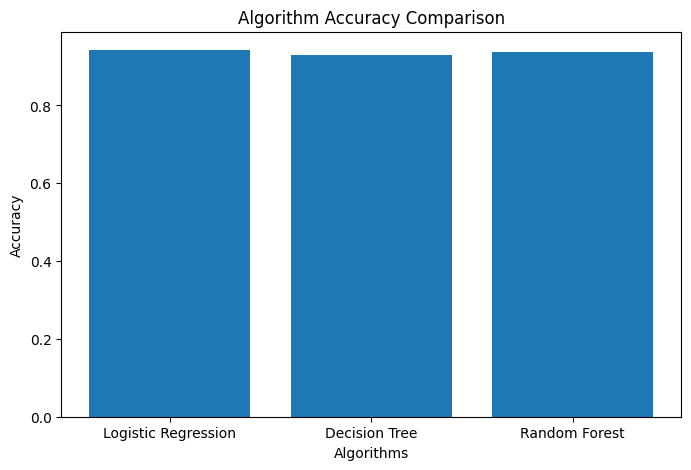

In [48]:
algorithms = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest'
]

accuracy_values = [
    lr_accuracy,
    dt_accuracy,
    rf_accuracy
]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(algorithms, accuracy_values)

plt.title("Algorithm Accuracy Comparison")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")

plt.show()

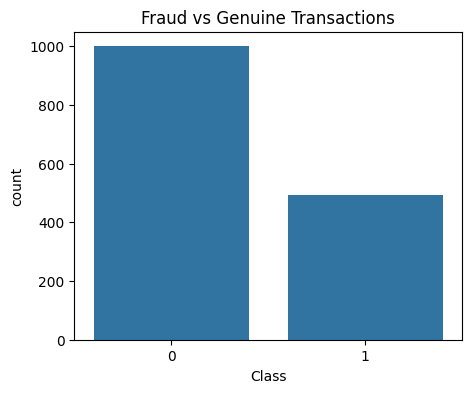

In [49]:
import seaborn as sns

plt.figure(figsize=(5,4))
sns.countplot(x='Class', data=data)

plt.title("Fraud vs Genuine Transactions")
plt.show()

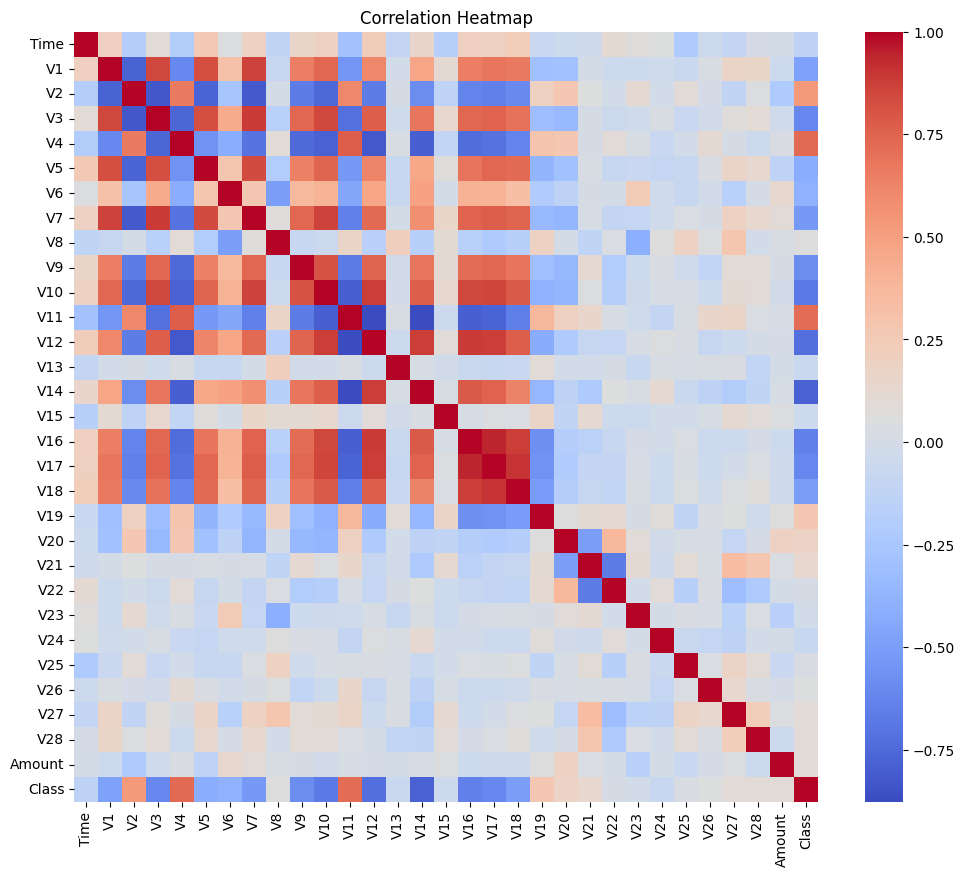

In [50]:
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [55]:
while True:

    print("\n========================================")
    print("    CREDIT CARD FRAUD DETECTION SYSTEM")
    print("========================================")
    print("1. View Sample Transactions")
    print("2. Predict Transaction")
    print("3. View Model Accuracy")
    print("4. Exit")

    choice = input("\nEnter your choice: ")

    if choice == "1":

        print("\nSample Transactions")
        display(data[['Time','Amount','Class']].head(10))

    elif choice == "2":

        row = int(input(f"\nEnter Transaction ID (0 to {len(data)-1}): "))

        if 0 <= row < len(data):

            sample = X[row].reshape(1, -1)

            prediction = rf_model.predict(sample)
            probability = rf_model.predict_proba(sample)

            print("\nTransaction Details")
            print(data.iloc[row][['Time','Amount']])

            if prediction[0] == 0:
                print("\nPrediction : Genuine Transaction")
            else:
                print("\nPrediction : Fraudulent Transaction")

            print("\nPrediction Probability")
            print(f"Genuine : {probability[0][0]*100:.2f}%")
            print(f"Fraud   : {probability[0][1]*100:.2f}%")

        else:
            print("Invalid Transaction ID")

    elif choice == "3":

        print("\nModel Accuracy")
        print(f"Logistic Regression : {lr_accuracy*100:.2f}%")
        print(f"Decision Tree       : {dt_accuracy*100:.2f}%")
        print(f"Random Forest       : {rf_accuracy*100:.2f}%")

    elif choice == "4":

        print("\nThank You!")
        break

    else:

        print("Invalid Choice! Please try again.")


    CREDIT CARD FRAUD DETECTION SYSTEM
1. View Sample Transactions
2. Predict Transaction
3. View Model Accuracy
4. Exit

Enter your choice: 1

Sample Transactions


,Time,Amount,Class
0,802.0,11.99,0
1,163070.0,34.02,0
2,102318.0,22.04,1
3,81231.0,3.56,0
4,43985.0,101.19,0
5,139188.0,22.00,0
6,27533.0,78.50,0
7,143759.0,25.98,0
8,120108.0,23.00,0
9,861.0,10.00,0



    CREDIT CARD FRAUD DETECTION SYSTEM
1. View Sample Transactions
2. Predict Transaction
3. View Model Accuracy
4. Exit

Enter your choice: 2

Enter Transaction ID (0 to 1491): 13

Transaction Details
Time      129308.0
Amount        80.9
Name: 13, dtype: float64

Prediction : Fraudulent Transaction

Prediction Probability
Genuine : 1.07%
Fraud   : 98.93%

    CREDIT CARD FRAUD DETECTION SYSTEM
1. View Sample Transactions
2. Predict Transaction
3. View Model Accuracy
4. Exit

Enter your choice: 3

Model Accuracy
Logistic Regression : 94.25%
Decision Tree       : 93.00%
Random Forest       : 93.75%

    CREDIT CARD FRAUD DETECTION SYSTEM
1. View Sample Transactions
2. Predict Transaction
3. View Model Accuracy
4. Exit

Enter your choice: 4

Thank You!
